In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from collections.abc import Hashable
from typing import NamedTuple, Generator
from anndata import AnnData
from itertools import product

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from anndata import AnnData
from numpy.typing import NDArray
from pandas import DataFrame
from scipy.stats import spearmanr, pearsonr
import torch

from utils import (
    filter_celltypes_by_size,
    group_by_common_obs, 
    mean_randomized_cross_feature_prediction
)
from nmf_utils import nmf_predictor
from nn_utils import nn_predictor
from tangram_utils import tangram_predictor

In [3]:
def _adata_sp() -> AnnData:
    adata_sp: AnnData = sc.read(
        Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
    ).transpose()
    obs: DataFrame = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
    adata_sp.obs = obs
    adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
    #adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype].copy()
    return adata_sp

def _adata_sc() -> AnnData:
    adata_sc: AnnData = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
    adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
    #adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype].copy()
    adata_sc.X = adata_sc.X.toarray()
    return adata_sc

data = (_adata_sp(), _adata_sc())
data = tuple(filter_celltypes_by_size(adata, "celltype", 20) for adata in data)

for adata in data:
    assert isinstance(adata.X, np.ndarray)
    sc.pp.filter_genes(adata, min_counts=1)

shared_genes = np.intersect1d(*tuple(adata.var_names for adata in data))

print(f"{data=}")
print(f"{len(shared_genes)=}")

data=(AnnData object with n_obs × n_vars = 7386 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts', AnnData object with n_obs × n_vars = 2194 × 21094
    obs: 'cluster', 'celltype'
    var: 'n_counts')
len(shared_genes)=202


In [4]:
from disk_cache import disk_cache
methods = {
    "nmf": disk_cache(Path("data/cache/benchmarking_refactor"))(nmf_predictor),
    #"tangram": disk_cache(Path("data/cache/benchmarking_refactor"))(tangram_predictor),
    "nn": disk_cache(Path("data/cache/benchmarking_refactor"))(nn_predictor),
}

In [5]:
results = []

for (method_name, method), (celltype, query, reference) in product(methods.items(), group_by_common_obs(*data, "celltype")):
    query_matrix = query[:, shared_genes].X
    reference_matrix = reference[:, shared_genes].X
    assert all(isinstance(m, np.ndarray) for m in (query_matrix, reference_matrix))
    
    reconstructed_counts = mean_randomized_cross_feature_prediction(
        query_matrix,
        reference_matrix,
        method,
        2,
        seed=5
    )
    
    score = float(spearmanr(query_matrix.mean(axis=0), reconstructed_counts.mean(axis=0))[0])
    results.append(((method_name, celltype), (query_matrix, reconstructed_counts)))

df = pd.DataFrame(results, columns=["index", "score"])
df.set_index("index", inplace=True)
df.index = pd.MultiIndex.from_tuples(df.index, names=["method", "celltype"])

In [6]:
df_spearman = pd.DataFrame(df["score"].map(lambda t: float(spearmanr(t[0].mean(axis=0), t[1].mean(axis=0))[0])))

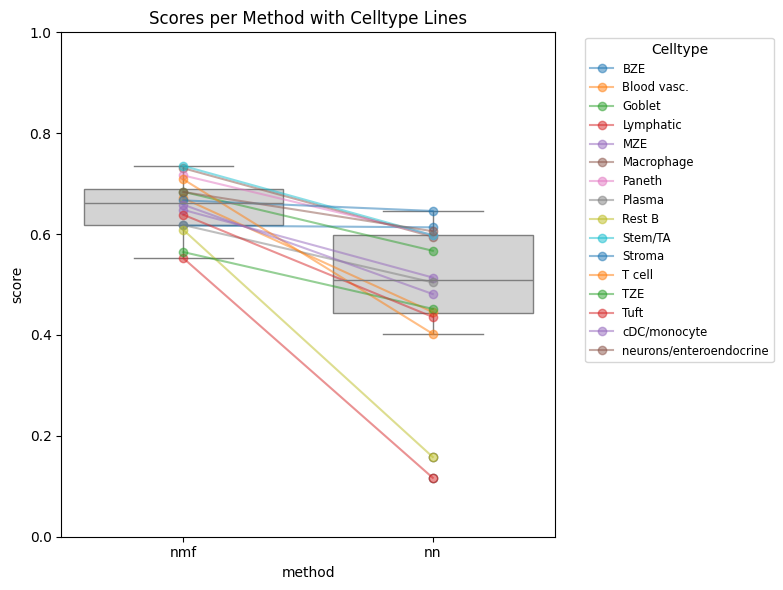

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_reset = df_spearman.reset_index()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")

for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title("Scores per Method with Celltype Lines")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
df_pearson = pd.DataFrame(df["score"].map(lambda t: float(pearsonr(t[0].mean(axis=0), t[1].mean(axis=0))[0])))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_reset = df_pearson.reset_index()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")

for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title("Scores per Method with Celltype Lines")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
from nn_utils import Model
model = Model(input, 10, target)

In [17]:
from utils import cross_feature_prediction


query_matrix, reference_matrix = tuple(map(
    lambda adata: adata[adata.obs["celltype"] == "Stem/TA"][:, shared_genes].X,
    data
))
res = cross_feature_prediction(
    query_matrix,
    reference_matrix,
    nn_predictor
)

SignificanceResult(statistic=np.float64(0.6720492739203463), pvalue=np.float64(6.7092706290574365e-28))
PearsonRResult(statistic=np.float32(0.69966733), pvalue=np.float64(5.01679598466743e-31))


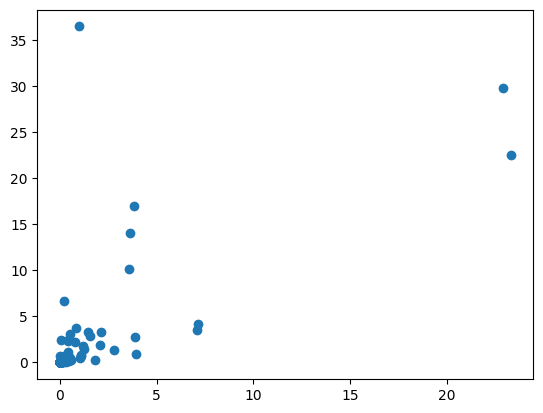

In [23]:
observed_mean = query_matrix.mean(axis=0)
predicted_mean = res.mean(axis=0)
plt.scatter(observed_mean, predicted_mean)
print(spearmanr(observed_mean, predicted_mean))
print(pearsonr(observed_mean, predicted_mean))

In [ ]:
losses = model.train(
    torch.optim.Adam,
    1,
    torch.nn.MSELoss(),
    500,
    verbose=True
)

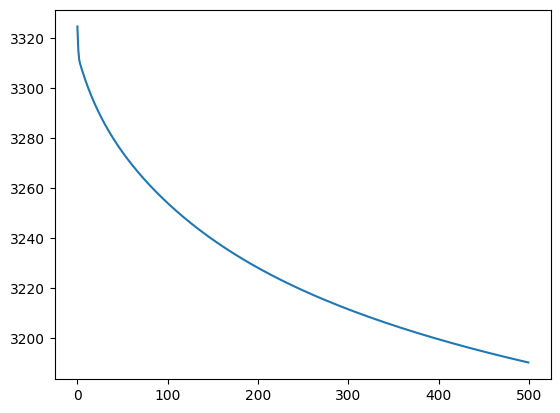

In [9]:
plt.plot(losses)

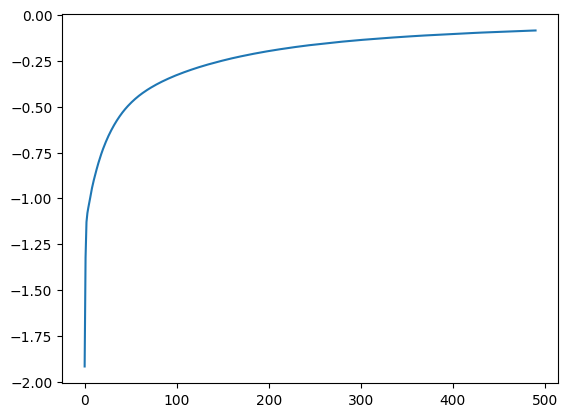

In [10]:
from scipy.stats import linregress
from numpy.lib.stride_tricks import sliding_window_view
regressions = [linregress(list(range(len(window))), window)[0].item() for window in sliding_window_view(np.array(losses), window_shape=10)]
plt.plot(regressions)


In [ ]:
regressions

In [ ]:
a

In [ ]:
model = Model(input, 10, target)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

losses: list[float] = []
for _ in range(50):
    output = model(input)
    loss = loss_fn(output, target)
    losses.append(loss.item())
    
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
from utils import get_aligned_gene_sets


arr1, arr2 = get_aligned_gene_sets(tuple(adata.var_names for adata in data))

In [ ]:
n_shared_genes = len(shared_genes)

In [ ]:
import torch

In [ ]:
input, target = tuple(torch.Tensor(data[1][:, arr].X) for arr in np.split(arr2, [n_shared_genes]))

In [ ]:
model = Model(n_input=input.shape[1], n_latent=10, n_output=target.shape[1])

In [ ]:
model(input).shape